# Data Mining 2026  — Project Notebook

**Course:** Data Mining  
**Project track:** ☑ Standard Analysis ☐ Research-Oriented

**Group members:**  
- Christian-Vlad Vladutu 
- Daniel Langdal Jensen
- Victor Bakkestrøm Poulsen

**Dataset:**  Oracle's Elixir League of Legends esports stats https://oracleselixir.com/tools/downloads (currently 2025 only)

**Initial task description (Module 1 perspective):** Clustering similar player performances, matches, players and teams. Finding outlier players and teams. 


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
cwd = Path('.')

### Load data

In [ ]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir.csv'
data: pd.DataFrame = pd.read_csv(data_path)
#data = data.iloc[:int(len(data)*0.11 / 12) * 12] # 10% of data for testing to make code run faster - must be divisible by 12 since each match has 12 rows
data_len = int(len(data) * 10 / 12)

C:\Users\victo\AppData\Local\Temp\ipykernel_33352\866007119.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data: pd.DataFrame = pd.read_csv(data_path)


### Duplicating data and removing surplus rows

The data consists of rows of match statistics for specific players. 

Since each match has 2 teams of 5 players, you would expect 10 rows for each match. It turns out that there are 12 rows for each match because there are 2 extra rows that contain information about the team as a whole, rather than the players. 

Since we want to analyze the players, we take the teamwide information contained in these 2 rows (which is simply missing information in the player rows) and duplicate it to the player rows of those teams in the places that the players are missing data (if present in the team data). 

In [3]:
for matchid in tqdm(data["gameid"].unique()):
    game = data[data["gameid"] == matchid]
    teams = game["teamid"].unique()

    for teamid in teams:
        team = game[game["teamid"] == teamid]

        players = team[team["position"] != "team"]
        team_stats = team[team["position"] == "team"]

        # fill missing values in players with team stats if available
        for column in data.columns:
            if players[column].isnull().any():
                data.loc[players.index, column] = team_stats[column].item()

  0%|          | 0/10053 [00:00<?, ?it/s]

skip running above cell by loading the full imputated data

In [14]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)
print(f"matches: {int(data_len/10)}, made up of {data_len} player performances")
print(f"number of columns: {data.shape[1]}")
print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")

C:\Users\victor\AppData\Local\Temp\ipykernel_17384\4168379563.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)


matches: 10053, made up of 100530 player performances
number of columns: 165
percentage categorical variables: 13.94%


Text(0.5, 1.0, 'percentage of missing values by column')

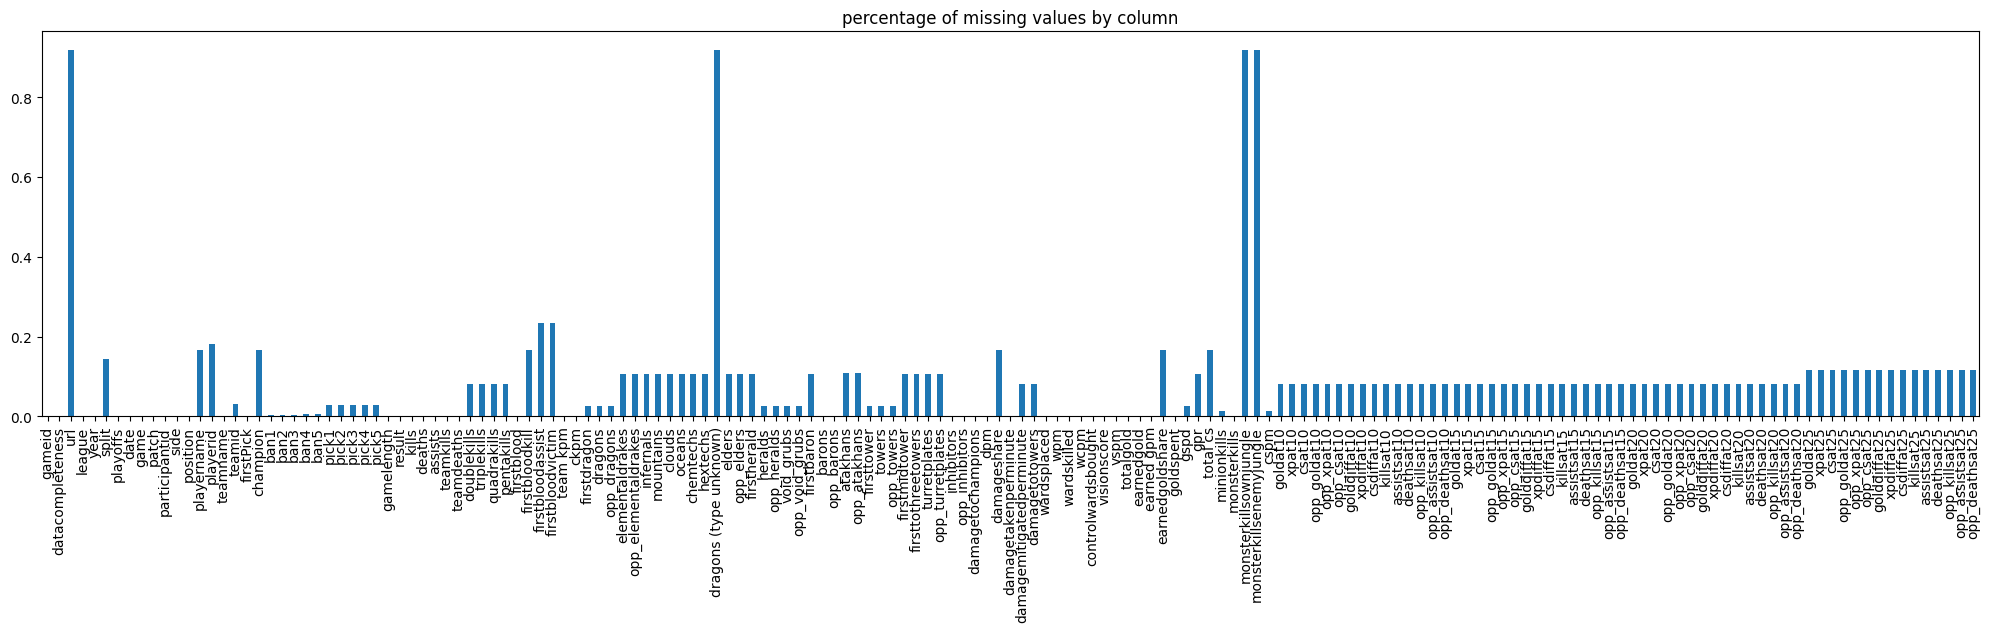

In [16]:
data.isnull().mean().plot(kind='bar', figsize=(25, 5))
plt.title('percentage of missing values by column')

In [ ]:
#data.to_csv("2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv")

We then drop all rows that only contain teamwide statistics, as we are currently interested in the player performances

In [17]:
data = data.drop(data[data["position"] == "team"].index) 

### Clean data for missing data and unrelated columns

Currently the data is full of missing values as can be seen on the missing value plot below, so we remove the the columns that have many missing values and then the rows that have many missing values. 

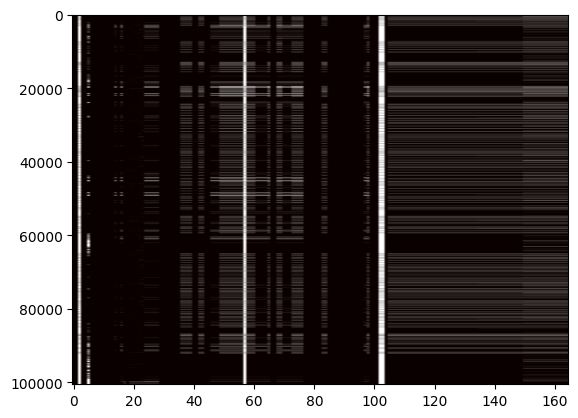

In [18]:
plt.imshow(data.isnull(), cmap='hot', aspect='auto')
plt.show()

In [19]:
# drop columns with more than a given percentage of missing values
missing_value_column_percentage_threshold = 0.20
missing_values = data.isnull().sum()
missing_value_columns = missing_values[missing_values > len(data) * missing_value_column_percentage_threshold].index
data = data.drop(columns=missing_value_columns)

# drop 10-rows (matches) with more than a given percentage of missing values
missing_value_row_percentage_threshold = 0
z = data.isnull().sum(axis=1)
gameids = data[z > len(data.columns) * missing_value_row_percentage_threshold]["gameid"].unique()

data = data.drop(data[data["gameid"].isin(gameids)].index)

The remaining data no longer contains a large amount of missing data as can be seen on the graph below, and still has 

In [20]:
100 * len(data) / data_len

71.58062269969163

% of the data rows, which represents 

In [21]:
len(data) / 10

7196.0

matches

### Modelling categorical variables as multivariate bernoulli variables (one-hot encoding)

In [41]:
# drop irrelevant columns
data_pure = data.drop(columns=["gameid", "split", "side", "datacompleteness", "league", "year", "playoffs", "date", "game", "patch", "participantid", "playername", "playerid", "teamname", "teamid"])

In [42]:
# convert categorical columns to one-hot encoding
data_numeric = pd.get_dummies(data_pure, dtype=float)
X = data_numeric.to_numpy()
X.shape

(71960, 1829)

This gives us a 1829-dimensional vector for each player-performance. Because of the curse of dimensionality this is too much to expect good results from, therefore we engineer a better vector by only keeping dimensions that are crucial for differentiating player performances. 

### Normalize data and calculate covariance and correlation matrix

In [43]:
X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=1)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

###  Clustering of known quantity

Can we make a clustering of player performances that clusters each player performance into one of the 5 league of legends roles (Top / Jungle / Mid / Bottom / Support)?

We use k-means clustering with $k=5$. 

We need to remove the one-hot encoded player role ("position" column) from the data, as this is what we are hoping to determine with our clustering.

In [44]:
position_indexes = np.where(("position_top" == data_numeric.columns) | ("position_jng" == data_numeric.columns) | ("position_mid" == data_numeric.columns) | ("position_bot" == data_numeric.columns) | ("position_sup" == data_numeric.columns))
X_hat = X_normalized
X_hat_no_position = np.delete(X_hat, position_indexes, axis=1)
X_cor_no_position = np.cov(X_hat_no_position, rowvar=False)

In [45]:
clustering = sklearn.cluster.KMeans(n_clusters=5).fit(X_hat_no_position)
for i in range(5):
    print(f"Cluster {i}:")
    print(data_pure["position"].iloc[np.where(clustering.labels_ == i)[0]].value_counts())
    print("")

Cluster 0:
position
top    4043
bot    3554
mid    3450
jng    2665
sup     675
Name: count, dtype: int64

Cluster 1:
position
jng    3684
sup    3677
top    2467
mid    1727
bot    1307
Name: count, dtype: int64

Cluster 2:
position
bot    5542
mid    3682
top    2331
jng    1236
sup     330
Name: count, dtype: int64

Cluster 3:
position
mid    4851
top    4555
bot    3269
jng    3141
sup    1032
Name: count, dtype: int64

Cluster 4:
position
sup    8678
jng    3666
top     996
bot     720
mid     682
Name: count, dtype: int64



We can see that we have one cluster where support is separated from the rest, but the other clusters are very mixed and don't really succeed in singling out specific roles. One reason this could be happening is due to the curse of dimensionality, we have 1800 dimensions and most of them are not important for clustering the points but having them increases the difficulty of the problem due to the curse of dimensionality. Our next approach is therefore to alleviate this by reducing the amount of dimensions. 

# Reducing the amount of dimensions

We pick out columns we have manually determined to likely play a big impact in differentiating player performances. Furthermore, we reduce the picked champion column from a one-hot encoding that takes 172 dimensions to a champion tag column that takes around 10 dimensions but is not a one-hot encoding, to do this we reduce the official league of legends champion class tags, for example, the champion Alistar is tagged as "Support" and "Tank", meaning the support and tank columns will have value 1, and the other columns will have value 0.

In [46]:
most_relevant_columns = ['champion', 'kills', 'deaths', 'assists','damagetochampions', 'dpm', 'damageshare', 'damagetakenperminute', 'damagemitigatedperminute', 'damagetotowers', 'wardsplaced', 'visionscore', 'totalgold', 'minionkills', 'monsterkills', 'xpat10', 'csat10', 'goldat10', 'xpat15', 'csat15', 'goldat15', 'xpat20', 'csat20', 'goldat20', 'xpat25', 'csat25', 'goldat25']
data_pure = data[most_relevant_columns + ["position"]]
from utility import champion_class_transform
import importlib
import sys
importlib.reload(sys.modules["utility"])
data_pure = champion_class_transform(data_pure)

In [47]:
data_pure

,kills,deaths,assists,damagetochampions,dpm,damageshare,damagetakenperminute,damagemitigatedperminute,damagetotowers,wardsplaced,...,xpat25,csat25,goldat25,position,Tank,Marksman,Assassin,Support,Mage,Fighter
0,1,2,1,20156,759.6482,0.401970,681.2186,629.7362,7451.0,9,...,12552.0,217.0,9244.0,top,1,0,0,0,0,1
1,0,3,1,4963,187.0477,0.098977,906.9724,954.6106,0.0,7,...,8877.0,139.0,7040.0,jng,1,0,0,1,0,0
2,1,2,0,13952,525.8291,0.278244,366.8593,241.0553,0.0,12,...,10669.0,200.0,8488.0,mid,0,0,0,1,1,0
3,1,3,1,6898,259.9749,0.137567,479.2085,282.9271,333.0,6,...,11763.0,251.0,9097.0,bot,0,1,0,0,0,0
4,0,3,2,4174,157.3116,0.083242,474.5352,534.1583,0.0,40,...,6259.0,38.0,5357.0,sup,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118925,7,4,3,23862,794.5172,0.208589,1115.0610,953.0411,15070.0,11,...,13582.0,163.0,9586.0,top,0,0,0,0,0,1
118926,4,2,13,24935,830.2442,0.217969,2077.7913,1721.7869,2169.0,8,...,13438.0,203.0,8909.0,jng,1,0,0,0,0,1
118927,11,1,8,33608,1119.0233,0.293784,630.5327,311.5871,10599.0,13,...,14576.0,213.0,11651.0,mid,0,0,1,0,1,0
118928,4,1,12,25955,864.2064,0.226885,641.8535,325.5716,3175.0,11,...,12314.0,259.0,11098.0,bot,0,1,0,0,0,0


In [51]:
# convert categorical columns to one-hot encoding
data_numeric = pd.get_dummies(data_pure, dtype=float)
X = data_numeric.to_numpy()
print(X.shape)

X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=1)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

position_indexes = np.where(("position_top" == data_numeric.columns) | ("position_jng" == data_numeric.columns) | ("position_mid" == data_numeric.columns) | ("position_bot" == data_numeric.columns) | ("position_sup" == data_numeric.columns))
X_hat = X_normalized
X_hat_no_position = np.delete(X_hat, position_indexes, axis=1)
X_cor_no_position = np.cov(X_hat_no_position, rowvar=False)

clustering = sklearn.cluster.KMeans(n_clusters=5).fit(X_hat_no_position)
for i in range(5):
    print(f"Cluster {i}:")
    print(data_pure["position"].iloc[np.where(clustering.labels_ == i)[0]].value_counts())
    print("\n")

(71960, 37)
Cluster 0:
position
bot    5437
mid    3499
top    2240
jng     888
sup     212
Name: count, dtype: int64


Cluster 1:
position
jng    5447
top    3815
sup    3796
mid    3140
bot    2075
Name: count, dtype: int64


Cluster 2:
position
top    3283
bot    2723
mid    2016
jng    1170
sup     321
Name: count, dtype: int64


Cluster 3:
position
sup    8836
jng    3404
top     909
mid     571
bot     512
Name: count, dtype: int64


Cluster 4:
position
mid    5166
top    4145
bot    3645
jng    3483
sup    1227
Name: count, dtype: int64




Our clustering is slightly better now, but still should be able to be much better. We can try to do a PCA dimensionality reduction to 2 dimensions and see if our data is clearly separable by position

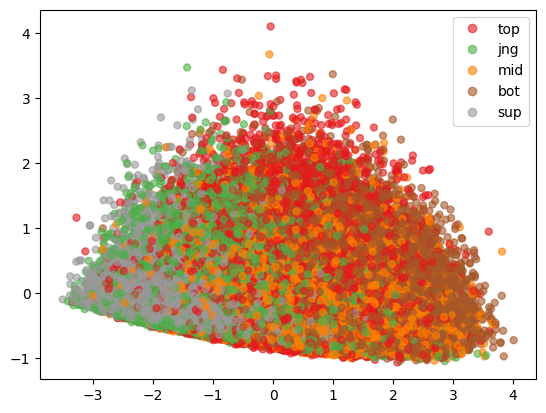

In [52]:
# plot pca with position as color
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat_no_position)
X_pca = pca.transform(X_hat_no_position)
z = {"top": 0, "jng": 1, "mid": 2, "bot": 3, "sup": 4}
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data_pure["position"].apply(lambda x: z[x]), cmap="Set1", s=25, alpha=0.6)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()

We can also do a T-sne plot, to see if our data can be better nonlinearly separated

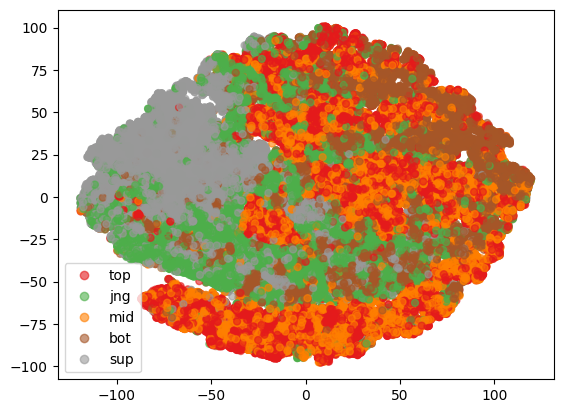

In [53]:
X_embedded = sklearn.manifold.TSNE(n_components=2, verbose=0).fit_transform(X_hat_no_position)
z = {"top": 0, "jng": 1, "mid": 2, "bot": 3, "sup": 4}
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=data_pure["position"].apply(lambda x: z[x]), cmap="Set1", s=25, alpha=0.6)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()

And we can see that the only clearly separable role is support. 


This may be due to the main variance in our data not being that of roles, but of other factors, such as whether or not the players won their games. If we do 2 clusters and look at the mean winrate in each cluster, we see that this is indeed the case (even though the result isn't a column included in our current data, it is being inferred through other variables): 

In [77]:
clustering = sklearn.cluster.KMeans(n_clusters=2).fit(X_hat_no_position)
print(np.mean(data.loc[clustering.labels_ == 0]["result"]))
print(np.mean(data.loc[clustering.labels_ == 1]["result"]))

0.5822452186162431
0.4133709981167608


Therefore, let's try filtering to only include won games. First we do a PCA plot: 

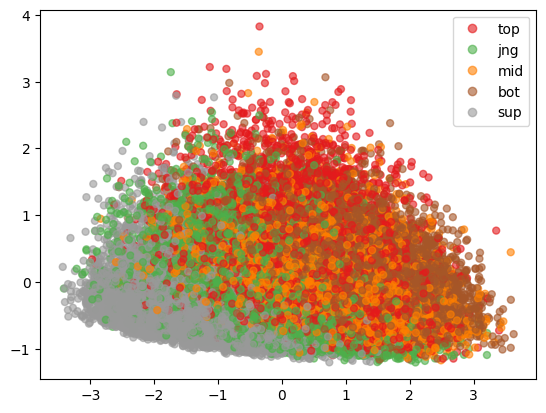

In [77]:
data_pure = data[data["result"] == 1]
data_pure = data_pure[most_relevant_columns + ["position"]]
data_pure = champion_class_transform(data_pure)
data_numeric = pd.get_dummies(data_pure, dtype=float)
X = data_numeric.to_numpy()
X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=1)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

position_indexes = np.where(("position_top" == data_numeric.columns) | ("position_jng" == data_numeric.columns) | ("position_mid" == data_numeric.columns) | ("position_bot" == data_numeric.columns) | ("position_sup" == data_numeric.columns))
X_hat = X_normalized
X_hat_no_position = np.delete(X_hat, position_indexes, axis=1)
X_cor_no_position = np.cov(X_hat_no_position, rowvar=False)

# plot pca with position as color
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat_no_position)
X_pca = pca.transform(X_hat_no_position)
z = {"top": 0, "jng": 1, "mid": 2, "bot": 3, "sup": 4}
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data_pure["position"].apply(lambda x: z[x]), cmap="Set1", s=25, alpha=0.6)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()


And we see that support is now slightly better distinguished, let's try clustering now, and let's also plot the average total gold for each cluster. 

In [78]:
clustering = sklearn.cluster.KMeans(n_clusters=5).fit(X_hat_no_position)
for i in range(5):
    print(f"Cluster {i}:")
    print(data_pure["position"].iloc[np.where(clustering.labels_ == i)[0]].value_counts())
    print(data.loc[data["result"] == 0].loc[clustering.labels_ == i]["totalgold"].mean())
    print("\n")

Cluster 0:
position
sup    5275
jng    1659
top     276
mid     146
bot      44
Name: count, dtype: int64
8213.620405405405


Cluster 1:
position
bot    2539
top    1736
mid    1407
jng     363
sup      52
Name: count, dtype: int64
11790.117598819092


Cluster 2:
position
top    1566
jng    1324
mid    1064
bot     785
sup     405
Name: count, dtype: int64
10151.81434681182


Cluster 3:
position
jng    3112
mid    2326
top    2185
sup    1312
bot     821
Name: count, dtype: int64
10978.512710127101


Cluster 4:
position
bot    3007
mid    2253
top    1433
jng     738
sup     152
Name: count, dtype: int64
13865.236186205988




As we can see the support-dominant cluster gets the least, while the "carry" (bot)-dominant cluster gets the most, which is expected. Let's also print the average game length for each cluster: 

In [79]:
clustering = sklearn.cluster.KMeans(n_clusters=5).fit(X_hat_no_position)
for i in range(5):
    print(f"Cluster {i}:")
    print(data.loc[data["result"] == 1].iloc[np.where(clustering.labels_ == i)[0]]["gamelength"].mean())
    print("")

Cluster 0:
1822.3121312684366

Cluster 1:
1886.4206243527149

Cluster 2:
1966.614063338701

Cluster 3:
2191.5033733750206

Cluster 4:
1889.6503271861986



This is unusual, since 1 role goes into every game which has a fixed game length, role clusters should not be formed based on infered game length. The fact that this is happening means that game length (and the columns correlated to game length, such as gold and xp) causes a large amount of variance in our data, and the clusters we are currently getting are probably not determined by roles but by gold/xp, and just happen to correlate decently with some roles like support and bot. We should thus normalize based on game length to alleviate this in order to form clusters that are based on roles rather than game length / gold / xp.

In order to normalize by game length we will take the average over all time-dependent columns for each time interval in our data and center our data around this mean while keeping the variance of each interval the same. 

<Axes: >

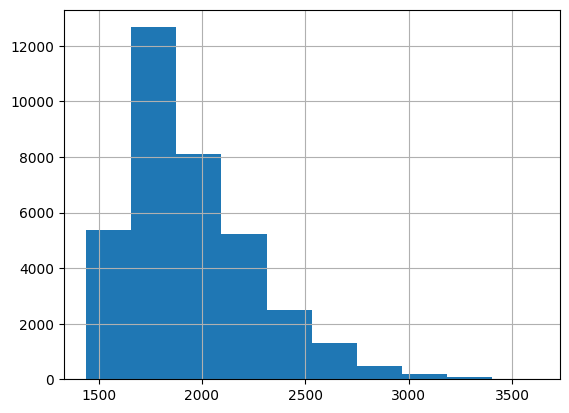

In [80]:
data.loc[data["result"] == 1]["gamelength"].hist()

In [81]:
min = np.min(data.loc[data["result"] == 1]["gamelength"])
max = np.max(data.loc[data["result"] == 1]["gamelength"])
k = 8
interval = (max - min) / k

for i in range(k):
    print(f'interval {(min + i * interval)/60:5.2f}m - {   (min + (i + 1) * interval)/60:5.2f}m: {len(data.loc[(data["result"] == 1) & (data["gamelength"] >= min + i * interval) & (data["gamelength"] < min + (i + 1) * interval)]):4d} games,  {data.loc[(data["result"] == 1) & (data["gamelength"] >= min + i * interval) & (data["gamelength"] < min + (i + 1) * interval)]["totalgold"].mean():5.2f} mean gold')

interval 24.00m - 28.54m: 8730 games,  11319.15 mean gold
interval 28.54m - 33.09m: 13475 games,  12400.35 mean gold
interval 33.09m - 37.63m: 8295 games,  13915.54 mean gold
interval 37.63m - 42.17m: 3385 games,  15395.45 mean gold
interval 42.17m - 46.72m: 1455 games,  16923.66 mean gold
interval 46.72m - 51.26m:  480 games,  18377.97 mean gold
interval 51.26m - 55.81m:  140 games,  19660.64 mean gold
interval 55.81m - 60.35m:   15 games,  22332.67 mean gold


In [82]:
time_dependent_columns = ["kills", "deaths", "assists","damagetochampions", "dpm", "damageshare", "damagetakenperminute", "damagemitigatedperminute", "damagetotowers", "wardsplaced", "visionscore", "totalgold", "minionkills", "monsterkills", "xpat10", "csat10", "goldat10", "xpat15", "csat15", "goldat15", "xpat20", "csat20", "goldat20", "xpat25", "csat25", "goldat25"]

for i in range(k):
    interval_indexes = data.loc[(data["result"] == 1) & (data["gamelength"] >= min + i * interval) & (data["gamelength"] < min + (i + 1) * interval)].index
    data_pure.loc[interval_indexes, time_dependent_columns] = data_pure.loc[interval_indexes, time_dependent_columns].astype(float) - data_pure.loc[interval_indexes, time_dependent_columns].mean()
    data_pure.loc[interval_indexes, time_dependent_columns] = data_pure.loc[interval_indexes, time_dependent_columns].astype(float) / data_pure.loc[interval_indexes, time_dependent_columns].std()

C:\Users\victor\AppData\Local\Temp\ipykernel_17384\2260304931.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.4580756 -3.4580756 -3.4580756 ...  7.5419244  6.5419244 -2.4580756]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_pure.loc[interval_indexes, time_dependent_columns] = data_pure.loc[interval_indexes, time_dependent_columns].astype(float) - data_pure.loc[interval_indexes, time_dependent_columns].mean()
C:\Users\victor\AppData\Local\Temp\ipykernel_17384\2260304931.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.50080183 -1.49919817 -0.49919817 ... -1.49919817  1.50080183
 -0.49919817]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_pure.loc[interval_indexes, time_dependent_columns] = data_pure.loc[interval_i

Now let's do a PCA plot again:

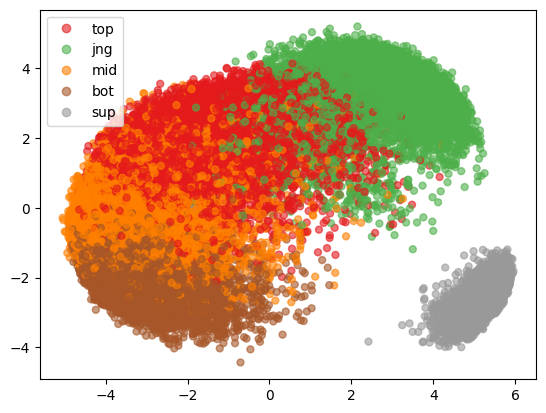

In [115]:
data_numeric = pd.get_dummies(data_pure, dtype=float)
X = data_numeric.to_numpy()
X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=1)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

position_indexes = np.where(("position_top" == data_numeric.columns) | ("position_jng" == data_numeric.columns) | ("position_mid" == data_numeric.columns) | ("position_bot" == data_numeric.columns) | ("position_sup" == data_numeric.columns))
X_hat = X_normalized
X_hat_no_position = np.delete(X_hat, position_indexes, axis=1)
X_cor_no_position = np.cov(X_hat_no_position, rowvar=False)

# plot pca with position as color
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat_no_position)
X_pca = pca.transform(X_hat_no_position)
z = {"top": 0, "jng": 1, "mid": 2, "bot": 3, "sup": 4}
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data_pure["position"].apply(lambda x: z[x]), cmap="Set1", s=25, alpha=0.6)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()


We can now see in the PCA plot that we get a much better distinction of roles, indicating that roles may now be some of the largest determiners of variance in our data. When we plot the average game length per cluster we also see now that they do not depend on game length: 

In [116]:
clustering = sklearn.cluster.KMeans(n_clusters=5).fit(X_hat_no_position)
for i in range(5):
    print(f"Cluster {i}:")
    print(data.loc[data["result"] == 1].iloc[np.where(clustering.labels_ == i)[0]]["gamelength"].mean())
    print("")

Cluster 0:
1955.0144030322174

Cluster 1:
1949.5644579983366

Cluster 2:
1949.0544921056307

Cluster 3:
1949.4870831376234

Cluster 4:
1945.390858081292



Let's print the role distribution in our clusters:

In [85]:
for i in range(5):
    print(f"Cluster {i}:")
    print(data_pure["position"].iloc[np.where(clustering.labels_ == i)[0]].value_counts())
    print("\n")

Cluster 0:
position
sup    7195
top      10
mid       5
jng       4
Name: count, dtype: int64


Cluster 1:
position
bot    6943
mid     677
top     274
jng      19
sup       1
Name: count, dtype: int64


Cluster 2:
position
jng    7153
top       3
mid       1
Name: count, dtype: int64


Cluster 3:
position
mid    5640
top    1417
bot     240
jng      20
Name: count, dtype: int64


Cluster 4:
position
top    5492
mid     873
bot      13
Name: count, dtype: int64




And we can see that we get a much better result. 

# Clustering of unknown quantity

## Clustering similar matches
We are also interested in finding out if there is some pattern in the players perfomance, are there clear clusters showing potential different types of perfomance, EG a average performance, above average, below average. Yet unlike above there is no base truth that we can compare it to so it makes more sense to use clustering density clustering algorithmns like DBSCAN to try and find clusters of perfomances that are similar to eachother.

Ideally we want points that are somewhat close, but we want a relatively high MinPts since we are looking to find more generalized clusters rather than highly specific clusters

In [117]:
X_hat = X_normalized


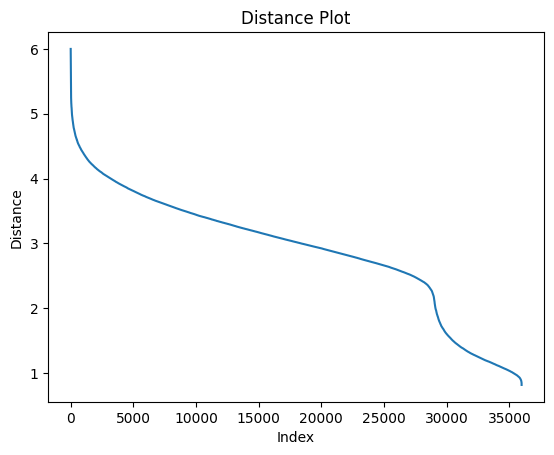

In [118]:
neighbors = 2*X_hat.shape[1]
nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=neighbors ).fit(X_hat)
distances, indices = nbrs.kneighbors(X_hat)
distance_desc = sorted(distances[:,neighbors-1], reverse=True)
plt.plot(
    range(1, len(distance_desc) + 1),
    distance_desc
)

plt.xlabel("Index")
plt.ylabel("Distance")
plt.title("Distance Plot")

plt.show()

In [119]:
density_cluster = sklearn.cluster.DBSCAN(eps=2.5, min_samples = neighbors).fit(X_hat)
labels = np.unique(density_cluster.labels_)
labels

array([-1,  0,  1,  2,  3,  4])

We see using this method we only get one cluster, which is not entirely surprising considering the very high dimensionality of the data which is causing min pts to be very large based on the heuristic. To try to alleviate this we cna use PCA to reduce dimensionality to hopefully improve the results.

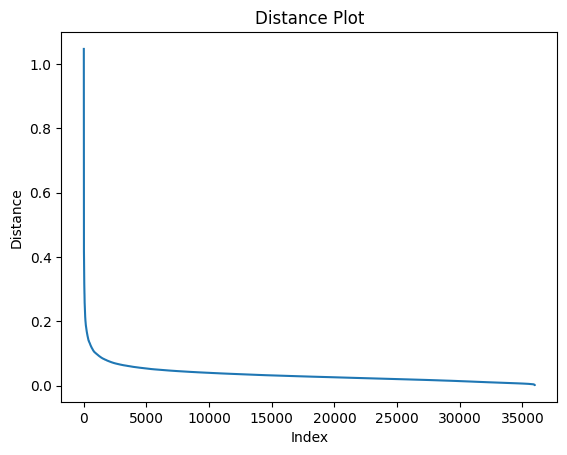

In [ ]:
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat)
X_pca = pca.transform(X_hat)

neighbors = 2*X_pca.shape[1]
nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=neighbors ).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)
distance_desc = sorted(distances[:,neighbors-1], reverse=True)
plt.plot(
    range(1, len(distance_desc) + 1),
    distance_desc
)

plt.xlabel("Index")
plt.ylabel("Distance")
plt.title("Distance Plot")

plt.show()

In [91]:
density_cluster = sklearn.cluster.DBSCAN(eps=0.3, min_samples = neighbors).fit(X_pca)
unique_labels = np.unique(density_cluster.labels_)
unique_labels

array([-1,  0,  1,  2,  3,  4,  5])

Now we are seeing a few too many clusters due to the rule of thumb for min pts not really working well for this type of data, as we ideally want to group games fall into more broad clusters. So we will manually set min pts to 20.

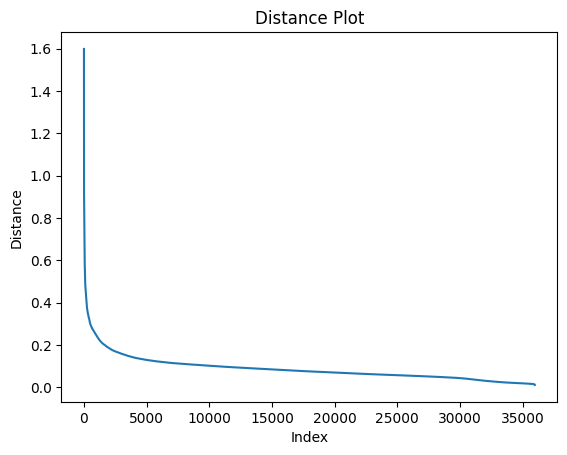

In [92]:
neighbors = 20
nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=neighbors ).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)
distance_desc = sorted(distances[:,neighbors-1], reverse=True)
plt.plot(
    range(1, len(distance_desc) + 1),
    distance_desc
)

plt.xlabel("Index")
plt.ylabel("Distance")
plt.title("Distance Plot")

plt.show()

In [93]:
density_cluster = sklearn.cluster.DBSCAN(eps=0.6, min_samples = neighbors).fit(X_pca)
unique_labels = np.unique(density_cluster.labels_)
labels = density_cluster.labels_
unique_labels

array([-1,  0,  1])

In [94]:
label_counts = np.unique(labels, return_counts=True)
label_counts

(array([-1,  0,  1]), array([   11, 28775,  7194]))

Now we are getting a more reasonable 3 clusters, though one cluster is highly represented 

In [95]:
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[density_cluster.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X_pca[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X_pca[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {len(unique_labels)-1}")
plt.show()

IndexError: index 9 is out of bounds for axis 0 with size 6

This can be read as that a vast perfomances being similar, though we should still try to investigate a bit further

We can try to use OPTICS instead since it is better suited for such high dimensional data